In [1]:
# FEM PROGRAM FOR TRUSS ANALYSIS


import numpy as np

# corresponds to phase II.1 (processing / assembling master stiffness matrix)
def PlaneTrussMasterStiffness(nodcoor, elenod, elemat, elefab):
    """
    INPUT: nodcoor (2D list nodal coords)
           elenod (element end nodes as 2D list)
           elemat (2D list with element properties [[Em1, Gm1, rho1, alpha1], ... ]
           elefab (element fabrication properties [[A1],...[Ae]], area)
           eleopt in the original allows for floating or symbolic calculation. 
    PROCESS:
    OUTPUT: K (global stiffness matrix)
    """
    numele = len(elenod)

    numnod = len(nodcoor)

    K = np.zeros((2 * numnod, 2 * numnod))

    for e in range (numele):
        ni, nj = elenod[e] 

        # element freedom table
        eftab = [2*ni -1, 2*ni, 2*nj-1, 2*nj]

        ncoor = [nodcoor[ni-1], nodcoor[nj-1]]

        mprop = elemat[e]
        fprop = elefab[e]

        Ke = PlaneBar2Stiffness(ncoor, mprop, fprop)
        
        neldof = Ke.shape[0] # length of rows
        for i in range(neldof):
            ii = eftab[i] - 1          # convert to Python indexing

            for j in range(i, neldof): # this loops only as upper triangular, lower tr. are copied symmetrically.
                jj = eftab[j] - 1

                K[ii, jj] += Ke[i, j] # append local stiffness entry to global matrix

                if ii != jj:
                    K[jj, ii] = K[ii, jj] # symmetry
    return K
    

def PlaneBar2Stiffness(ncoor, mprop, fprop):
    """
    INPUT: ncoor (array [[x1, y1], [x2,y2]]), mprop (E, G, rho, alpha), fprop (Area, input as list), 
        SIDENOTE: original Felippa code includes "numer" as option for numerical computation instead of symbolic. 
    PROCESS: computes stiffness matrix
    OUTPUT: Ke stiffness matrix
    """

    (x1, y1), (x2, y2) = ncoor
    
    x21 = x2 - x1
    y21 = y2 - y1
    
    Em, Gm, rho, alpha = mprop
    (A,) = fprop

    LL = x21**2+y21**2 
    L = np.sqrt(LL)
    LLL = LL*L

    Ke = (Em*A/LLL) * np.array([
        [ x21*x21,  x21*y21, -x21*x21, -x21*y21],
        [ y21*x21,  y21*y21, -y21*x21, -y21*y21],
        [-x21*x21, -x21*y21,  x21*x21,  x21*y21],
        [-y21*x21, -y21*y21,  y21*x21,  y21*y21]
    ])

    return Ke



In [2]:
nodcoor = [[0,0], [10, 0], [10, 10]]
elenod = [[1,2], [2,3], [1,3]]
elemat = [[100, 0, 0, 0]] * 3
elefab = [[1], [0.5], [2*np.sqrt(2)]]
K = PlaneTrussMasterStiffness(nodcoor, elenod, elemat, elefab)
print("Master Stiffness of Example Truss:")
print(K)


eigvals = np.linalg.eigvalsh(K)
eigvals = np.where(np.abs(eigvals)<1e-10, 0, eigvals)
print(eigvals)

Master Stiffness of Example Truss:
[[ 20.  10. -10.   0. -10. -10.]
 [ 10.  10.   0.   0. -10. -10.]
 [-10.   0.  10.   0.   0.   0.]
 [  0.   0.   0.   5.   0.  -5.]
 [-10. -10.   0.   0.  10.  10.]
 [-10. -10.   0.  -5.  10.  15.]]
[ 0.          0.          0.          7.90199615 16.74030849 45.35769536]


In [3]:
# corresponds to phase II.2 DBC modifies stiffness matrix

def ModifiedMasterStiffness(pdof, K): 
    """
    INPUT: pdof (list of prescribed DoF), K (master stiffness matrix)
    PROCESS:
    OUTPUT: Kmod (modified MSM)
    """
    n = K.shape[0]
    npdof = len(pdof) # in the Felippa version, this variable is np. To avoid problems with numpy I preferred 'npdof'

    Kmod = K.copy()
    for k in range(npdof):
        i = pdof[k] - 1
        
        for j in range(n):
            Kmod[i,j] = Kmod [j, i] = 0
            
        Kmod [i,i] = 1

    return Kmod

def ModifiedNodeForces(pdof, f):
    """
    INPUT: pdof (list of prescribed DoF), f (force vector)
    PROCESS:
    OUTPUT: fmod (modified force vector)
    """
    npdof = len(pdof)

    fmod = f.copy()

    for k in range(npdof):
        i = pdof[k] - 1
        fmod[i] = 0

    return fmod





In [4]:
print("Assembled Master Stiffness:")
print(K)
K = ModifiedMasterStiffness([1,2,4], K)
print("Master Stiffness Modified for Displacement B.C.:")
print(K)

Assembled Master Stiffness:
[[ 20.  10. -10.   0. -10. -10.]
 [ 10.  10.   0.   0. -10. -10.]
 [-10.   0.  10.   0.   0.   0.]
 [  0.   0.   0.   5.   0.  -5.]
 [-10. -10.   0.   0.  10.  10.]
 [-10. -10.   0.  -5.  10.  15.]]
Master Stiffness Modified for Displacement B.C.:
[[ 1.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.]
 [ 0.  0. 10.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0. 10. 10.]
 [ 0.  0.  0.  0. 10. 15.]]


In [5]:
def PlaneTrussIntForces(nodcoor, elenod, elemat, elefab, u):
    """
    INPUT: nodcoor (2D list nodal coords)
           elenod (element end nodes as 2D list)
           elemat (2D list with element properties [[Em1, Gm1, rho1, alpha1], ... ]
           elefab (element fabrication properties [[A1],...[Ae]], area)
           u (displacement)
    PROCESS:
    OUTPUT: p (internal forces in entire truss)
    """
    numele = len(elenod)
    numnod = len(nodcoor)

    p = np.zeros(numele)
    ue = np.zeros(4)

    for e in range(numele):
        ni, nj = elenod[e]
        eftab = [2*ni -1, 2*ni, 2*nj-1, 2*nj] 

        ncoor = [nodcoor[ni-1], nodcoor[nj-1]]

        mprop = elemat[e]
        fprop = elefab[e]
        for i in range(4):
            ii = eftab[i] - 1
            ue[i] = u[ii]
        p[e] = PlaneBar2IntForce(ncoor,mprop, fprop, ue)

    return p 


def PlaneBar2IntForce(ncoor, mprop, fprop, ue):
    """
    INPUT: ncoor (array [[x1, y1], [x2,y2]]), mprop (E, G, rho, alpha), fprop (Area, input as list), ue (disp)
    PROCESS: 
    OUTPUT: p (given internal force)
    """
    (x1, y1), (x2, y2) = ncoor
    
    x21 = x2 - x1
    y21 = y2 - y1

    Em, Gm, rho, alpha = mprop
    (A,) = fprop

    LL = x21**2+y21**2 

    pe = Em * A * (x21 *(ue[2] - ue[0]) + y21 * (ue[3] - ue[1])) / LL

    return pe



In [6]:

nodcoor = [[0,0],[10,0],[10,10]]
elenod = [[1,2],[2,3],[1,3]]

elemat = [[100,0,0,0]]*3
elefab = [[1],[0.5],[2*np.sqrt(2)]]

u = [0,0,0,0,0.4,-0.2]

p = PlaneTrussIntForces(nodcoor, elenod, elemat, elefab, u)
print("Int Forces of Example Truss:")
print(p)

Int Forces of Example Truss:
[ 0.         -1.          2.82842712]


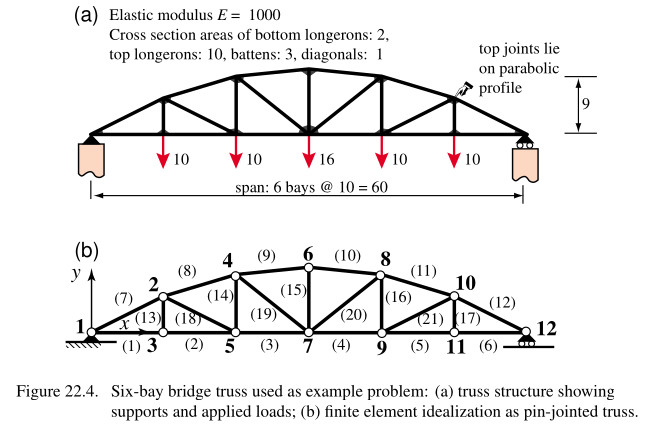


In [7]:
# DRIVER FOR ANALYSIS OF THE BRIDGE TRUSS: PREPROCESSING

# 6-bay bridge truss

NodeCoordinates = [[0, 0],[10, 5],[10, 0],[20, 8],[20, 0],[30, 9],
                   [30, 0],[40, 8],[40, 0],[50, 5],[50, 0],[60, 0],]

ElemNodeLists = [[1, 3],[3, 5],[5, 7],[7, 9],[9, 11],[11, 12],
                 [1, 2],[2, 4],[4, 6],[6, 8],[8, 10],[10, 12],
                 [2, 3],[4, 5],[6, 7],[8, 9],[10, 11],
                 [2, 5],[4, 7],[7, 8],[9, 10]]

numnod = len(NodeCoordinates)
numele = len(ElemNodeLists)
numdof = 2*numnod

ElemMaterial = [[1000, 0, 0, 0] for _ in range(numele)]

Abot = 2; Atop = 10;Abat= 3; Adia = 1 #areas of bottom, top bars, battens, and diagonals

ElemFabrication = (
    [[Abot]] * 6 +
    [[Atop]] * 6 +
    [[Abat]] * 5 +
    [[Adia]] * 4
)

# PlotLineElements


# FreedomValue: 2D list that specifies freedom values by node (forces in x, y by node)
# Freedom Tag: 2D list that specifies whether displacement is prescribed. [1,1] means both ux, uy are fixed.
FreedomValue = [[0,0] for _ in range(numnod)]
# hardcode force values into respective bottom longerons (see image above). Python index - 1.
FreedomValue[2] = [0, -10]
FreedomValue[4] = [0, -10]
FreedomValue[6] = [0, -16]
FreedomValue[8] = [0, -10]
FreedomValue[10] = [0, -10]
print("Applied node forces=")
print(FreedomValue)

FreedomTag = [[0,0] for _ in range(numnod)]
FreedomTag[0] = [1,1] # fixed node 1
FreedomTag[numnod-1] = [0, 1] # hroller @ node 12

f = np.array(FreedomValue, dtype=float).flatten()

K = PlaneTrussMasterStiffness(NodeCoordinates, ElemNodeLists, ElemMaterial, ElemFabrication)

pdof = []

# prescribed DoF array pdof
for n in range(numnod):
    for j in range(2):
        if FreedomTag[n][j] > 0:
            pdof.append(2 * n + j + 1)

Kmod = ModifiedMasterStiffness(pdof, K)
fmod = ModifiedNodeForces(pdof, f)
u = np.linalg.solve(Kmod,fmod)
u = np.where(np.abs(u) < 1e-10, 0, u)
print("Computed Nodal Displacements:")
print(u)
f = K @ u
f =  np.where(np.abs(f) < 1e-10, 0, f)
print("External Node Forces Including Reactions:")
print(f)

p = PlaneTrussIntForces(NodeCoordinates, ElemNodeLists, ElemMaterial, ElemFabrication, u)
p = np.where(np.abs(p) < 1e-10, 0, p)

sigma = [float(p[i] / ElemFabrication[i][0]) for i in range(numele)]
print("Internal Member Forces:")
print(p)

#PlotTrussDeformedShape

#PlotAxialStressLevel


Applied node forces=
[[0, 0], [0, 0], [0, -10], [0, 0], [0, -10], [0, 0], [0, -16], [0, 0], [0, -10], [0, 0], [0, -10], [0, 0]]
Computed Nodal Displacements:
[ 0.          0.          0.80953632 -1.7755974   0.28       -1.79226406
  0.89900137 -2.29192964  0.56       -2.31659631  0.8475     -2.38593838
  0.8475     -2.42193838  0.79599863 -2.29192964  1.135      -2.31659631
  0.88546368 -1.7755974   1.415      -1.79226406  1.695       0.        ]
External Node Forces Including Reactions:
[  0.  28.   0.   0.   0. -10.   0.   0.   0. -10.   0.   0.   0. -16.
   0.   0.   0. -10.   0.   0.   0. -10.   0.  28.]
Internal Member Forces:
[ 56.          56.          57.5         57.5         56.
  56.         -62.60990337 -60.03176243 -60.29925373 -60.29925373
 -60.03176243 -62.60990337  10.           9.25        12.
   9.25        10.           1.67705098   3.20156212   3.20156212
   1.67705098]


In [8]:
# POSTPROCESSING PLOT MODULES 

# I couldn't find anywhere, so these modules try to replicate the output shown in the chapter. Take them with a big grain of salt. 

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


def SetPlotFrame(ax, aspect, title):
    """
    INPUT: ax (matplotlib Axes), aspect (plot aspect ratio),
           title (placed above the plot)
    PROCESS: applies the frame styling shared by the three plot modules
    OUTPUT: none (ax is modified in place)
    """
    if aspect <= 0:
        ax.set_aspect('equal')          # true proportions, Felippa's aspect=0
    else:
        ax.set_aspect(aspect)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.margins(0.08)
    ax.grid(True, linewidth=0.3, alpha=0.3)


def PlotLineElements(nodcoor, elenod, aspect, title):
    """
    INPUT: nodcoor (2D list nodal coords), elenod (element end nodes as 2D list),
           aspect (plot aspect ratio),
           title ( placed above the plot)
    PROCESS: draws each element as a straight segment between its two end nodes
    OUTPUT: fig, ax
    """
    numele = len(elenod)
    numnod = len(nodcoor)

    fig, ax = plt.subplots(figsize=(9, 3.5))

    for e in range(numele):
        ni, nj = elenod[e]

        x1, y1 = nodcoor[ni-1]      # python indexing
        x2, y2 = nodcoor[nj-1]

        ax.plot([x1, x2], [y1, y2], color='black', linewidth=1.0, zorder=1)

    x = [nodcoor[n][0] for n in range(numnod)]
    y = [nodcoor[n][1] for n in range(numnod)]
    ax.plot(x, y, linestyle='none', marker='o', markersize=4,
            markerfacecolor='white', markeredgecolor='black', zorder=2)

    SetPlotFrame(ax, aspect, title)
    plt.show()
    return fig, ax


def PlotTrussDeformedShape(nodcoor, elenod, u, amplif, aspect, title):
    """
    INPUT: nodcoor (2D list nodal coords), elenod (element end nodes as 2D list), u ( displ.),
           amplif (displacement magnification factor),
           aspect (plot aspect ratio),
           title ( placed above the plot)
    PROCESS: superposes the undeformed mesh on the amplified deformed mesh 
    OUTPUT: fig, ax
    """
    numele = len(elenod)
    numnod = len(nodcoor)

    # amplified deformed nodal coordinates, node by node
    defcoor = []
    for n in range(numnod):
        x, y = nodcoor[n]
        ux = u[2*n]          # python index 2n
        uy = u[2*n + 1]      # python index 2n+1
        defcoor.append([x + amplif*ux, y + amplif*uy])

    fig, ax = plt.subplots(figsize=(9, 3.5))

    for e in range(numele):
        ni, nj = elenod[e]

        x1, y1 = nodcoor[ni-1]      # undeformed
        x2, y2 = nodcoor[nj-1]
        ax.plot([x1, x2], [y1, y2], color='0.65', linewidth=0.8,
                linestyle='--', zorder=1)

        x1, y1 = defcoor[ni-1]      # deformed
        x2, y2 = defcoor[nj-1]
        ax.plot([x1, x2], [y1, y2], color='tab:blue', linewidth=1.4, zorder=2)

    x = [defcoor[n][0] for n in range(numnod)]
    y = [defcoor[n][1] for n in range(numnod)]
    ax.plot(x, y, linestyle='none', marker='o', markersize=4,
            markerfacecolor='white', markeredgecolor='tab:blue', zorder=3)

    SetPlotFrame(ax, aspect, title + f"  (magnification {amplif})")
    plt.show()
    return fig, ax


def PlotAxialStressLevel(nodcoor, elenod, sigma, amplif, aspect, title):
    """
    INPUT: nodcoor (2D list nodal coords), elenod (element end nodes as 2D list), sigma, amplif (amplifies line width),
           aspect (plot aspect ratio),
           title (string placed above the plot)
    PROCESS: colors each element by its axial stress 
    OUTPUT: fig, ax
    """
    numele = len(elenod)
    numnod = len(nodcoor)

    # symmetric color scale so tension and compression are comparable
    smax = max(abs(float(s)) for s in sigma)
    if smax == 0:
        smax = 1.0
    norm = plt.Normalize(vmin=-smax, vmax=smax)
    cmap = plt.get_cmap('coolwarm')

    segments = []
    colors = []
    widths = []
    for e in range(numele):
        ni, nj = elenod[e]

        x1, y1 = nodcoor[ni-1]     
        x2, y2 = nodcoor[nj-1]

        segments.append([(x1, y1), (x2, y2)])
        colors.append(cmap(norm(float(sigma[e]))))
        widths.append(amplif * (1.0 + 4.0*abs(float(sigma[e]))/smax))

    fig, ax = plt.subplots(figsize=(9, 3.5))

    lc = LineCollection(segments, colors=colors, linewidths=widths, zorder=1)
    ax.add_collection(lc)

    x = [nodcoor[n][0] for n in range(numnod)]
    y = [nodcoor[n][1] for n in range(numnod)]
    ax.plot(x, y, linestyle='none', marker='o', markersize=4,
            markerfacecolor='white', markeredgecolor='black', zorder=2)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("axial stress")

    SetPlotFrame(ax, aspect, title)
    plt.show()
    return fig, ax

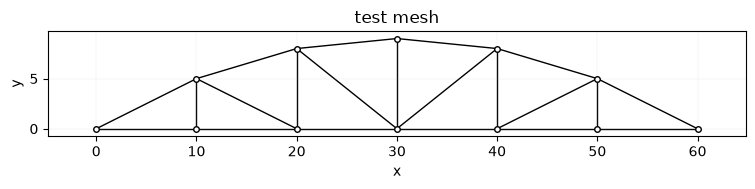

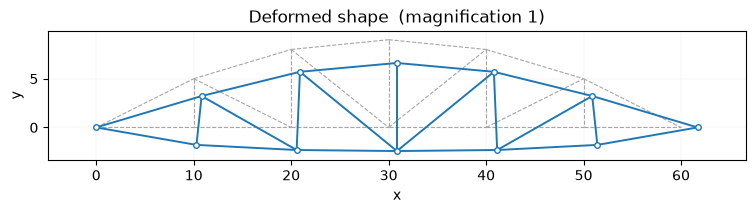

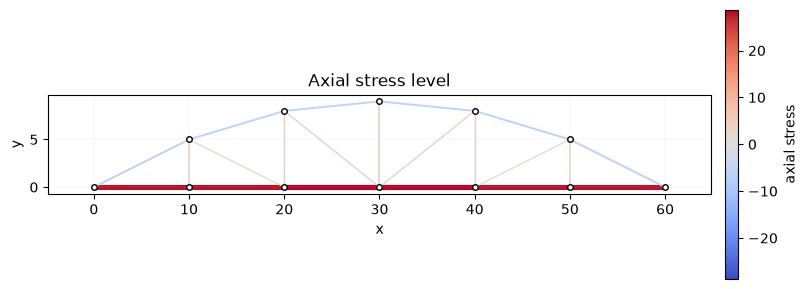

(<Figure size 900x350 with 2 Axes>,
 <Axes: title={'center': 'Axial stress level'}, xlabel='x', ylabel='y'>)

In [9]:

aspect = 0
PlotLineElements(NodeCoordinates, ElemNodeLists, aspect, "test mesh")

PlotTrussDeformedShape(NodeCoordinates, ElemNodeLists, u,
                       1, aspect, "Deformed shape")

PlotAxialStressLevel(NodeCoordinates, ElemNodeLists, sigma,
                     0.75, aspect, "Axial stress level")


In [10]:
# ANIMATED DEFORMED SHAPE (beyond the scope of the chapter, but seemed like a cool thing to add)

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def TrussDeformedCoordinates(nodcoor, u, amplif):
    """
    INPUT: nodcoor (2D list nodal coords), u (displ.),
           amplif (displacement magnification factor)
    PROCESS: adds the amplified nodal displacements to the reference coordinates
    OUTPUT: defcoor (2D list of amplified deformed nodal coords)
    """
    numnod = len(nodcoor)

    defcoor = []
    for n in range(numnod):
        x, y = nodcoor[n]
        ux = u[2*n]          # 1-based dof 2n-1 -> Python index 2n
        uy = u[2*n + 1]      # 1-based dof 2n   -> Python index 2n+1
        defcoor.append([x + amplif*ux, y + amplif*uy])

    return defcoor


def AnimateTrussDeformedShape(nodcoor, elenod, u, amplif, aspect, title,
                              numframe=40, pingpong=True):
    """
    INPUT: nodcoor (2D list nodal coords), elenod (element end nodes as 2D list), u (displ.),
           amplif (final displacement magnification factor),
           aspect (plot aspect ratio),
           title (placed above the plot),
           numframe (frames used to ramp from undeformed to fully deformed),
           pingpong (if True the ramp is played forward then backward)
    PROCESS: sweeps the magnification from 0 to amplif, redrawing the mesh at each step. Axis limits are locked to the fully deformed extent so that the
             supported nodes stay put.
    OUTPUT: anim (matplotlib FuncAnimation object)
    """
    numele = len(elenod)
    numnod = len(nodcoor)

    # magnification
    ramp = list(np.linspace(0.0, amplif, numframe))
    if pingpong:
        ramp = ramp + ramp[-2:0:-1]

    # lock the frame to the fully deformed extent
    fullcoor = TrussDeformedCoordinates(nodcoor, u, amplif)
    allx = [nodcoor[n][0] for n in range(numnod)] + \
           [fullcoor[n][0] for n in range(numnod)]
    ally = [nodcoor[n][1] for n in range(numnod)] + \
           [fullcoor[n][1] for n in range(numnod)]
    padx = 0.05*(max(allx) - min(allx))
    pady = 0.05*(max(ally) - min(ally))

    fig, ax = plt.subplots(figsize=(9, 3.5))

    # undeformed mesh
    for e in range(numele):
        ni, nj = elenod[e]

        x1, y1 = nodcoor[ni-1]      
        x2, y2 = nodcoor[nj-1]

        ax.plot([x1, x2], [y1, y2], color='0.75', linewidth=0.8,
                linestyle='--', zorder=1)

    # deformed mesh redrawn every frame
    lc = LineCollection([], colors='tab:blue', linewidths=1.4, zorder=2)
    ax.add_collection(lc)
    dots, = ax.plot([], [], linestyle='none', marker='o', markersize=4,
                    markerfacecolor='white', markeredgecolor='tab:blue',
                    zorder=3)

    ax.set_xlim(min(allx) - padx, max(allx) + padx)
    ax.set_ylim(min(ally) - pady, max(ally) + pady)
    ax.margins(0)
    SetPlotFrame(ax, aspect, title)

    def DrawFrame(k):
        a = ramp[k]
        defcoor = TrussDeformedCoordinates(nodcoor, u, a)

        segments = []
        for e in range(numele):
            ni, nj = elenod[e]

            x1, y1 = defcoor[ni-1]
            x2, y2 = defcoor[nj-1]

            segments.append([(x1, y1), (x2, y2)])

        lc.set_segments(segments)
        dots.set_data([defcoor[n][0] for n in range(numnod)],
                      [defcoor[n][1] for n in range(numnod)])
        ax.set_title(f"{title}   (load {100*a/amplif:.0f}%,"
                     f" magnification {a:.2f})")
        return lc, dots

    anim = FuncAnimation(fig, DrawFrame, frames=len(ramp),
                         interval=50, blit=False)
    plt.close(fig)          # suppress the static duplicate in Jupyter
    return anim

In [11]:


anim = AnimateTrussDeformedShape(NodeCoordinates, ElemNodeLists, u,
                                 1.0, aspect, "Deformed shape",
                                 numframe=40, pingpong=True)
HTML(anim.to_jshtml())
